---

# ASSIGNMENT 3: BAR CHARTS

---

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
transactions = pd.read_csv('Data/transactions.csv', parse_dates=['date'])

# preparing the dataset for plotting
df_plot = (transactions
    .query("store_nbr in [1, 2, 3, 4] ")
    .groupby('store_nbr')[['transactions']].sum()
    .sort_values(by='transactions', ascending=False)
)

df_plot.head()

,transactions
store_nbr,
3,5366350
2,3219901
1,2553963
4,2519007


<Axes: title={'center': 'Total Sum of Transactions for Stores 1 to 4'}, xlabel='Store Number', ylabel='Total Amount of Transactions [Millions]'>

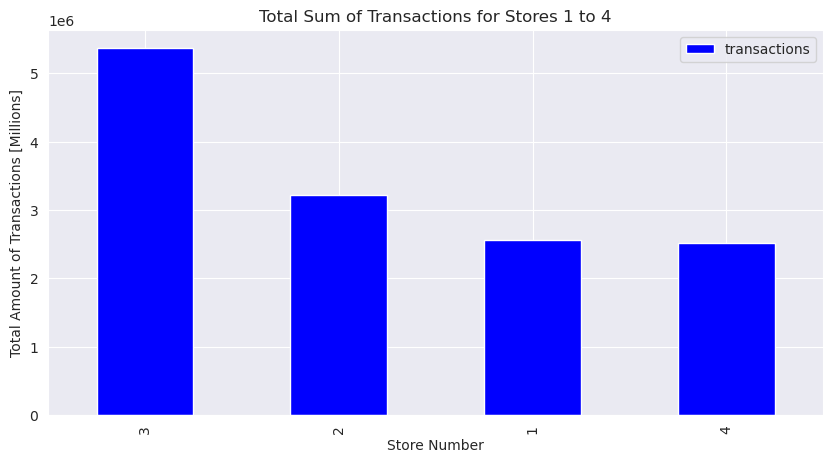

In [3]:
# Plot No.1
sns.set_style('darkgrid')

df_plot.plot.bar(
    figsize=(10,5),
    title='Total Sum of Transactions for Stores 1 to 4',
    xlabel='Store Number',
    ylabel='Total Amount of Transactions [Millions]',
    cmap='winter'
)

In [4]:
df_plot2 = (transactions
    .query("store_nbr in [1,2,3,4]")
    .pivot_table(index=transactions.date.dt.month, columns='store_nbr', values='transactions', aggfunc='sum'))

df_plot2

store_nbr,1,2,3,4
date,,,,
1,229203,284134,463260,222075
2,209400,265922,437238,209211
3,232178,293076,487224,231837
4,229081,287325,478308,223928
5,231160,293588,491961,228753
6,231514,284835,474668,222678
7,236032,288783,484698,224327
8,202821,255475,431752,200100
9,182035,228658,379101,178172


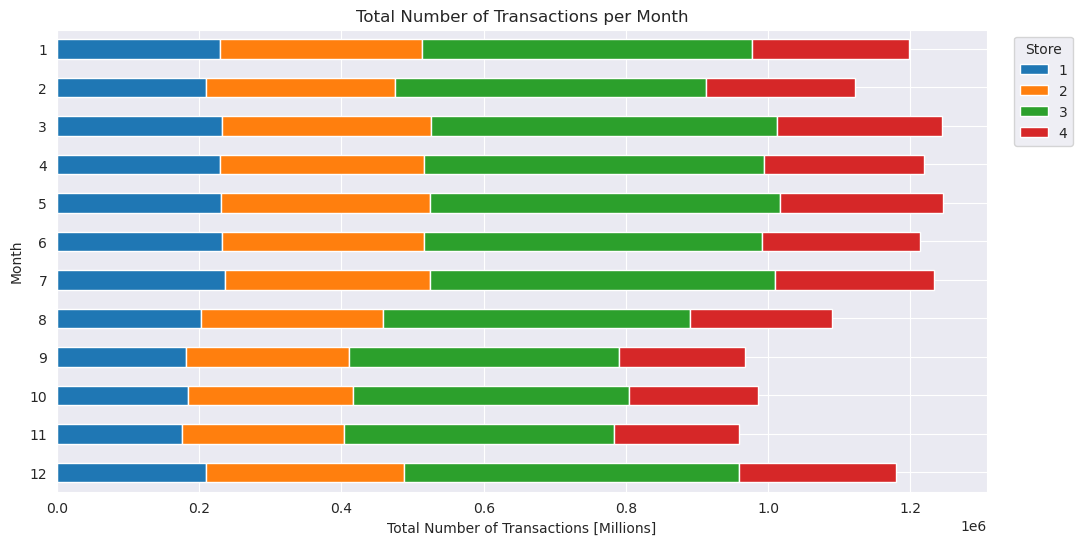

In [10]:
ax = df_plot2.iloc[::-1].plot.barh(
    figsize=(12, 6),
    stacked=True,
    title='Total Number of Transactions per Month',
    ylabel='Month',
    xlabel='Total Number of Transactions [Millions]'
)
ax.legend(bbox_to_anchor=(1.1,1), title='Store');